In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib as mpl
import numpy as np
import pandas as pd
from imodels_experiments.util import DATASET_PATH

mpl.rcParams['figure.dpi'] = 250

# change working directory to project root
if os.getcwd().split('/')[-1] == 'imodels_experiments/notebooks':
    os.chdir('../..')
from imodels.util.data_util import get_clean_dataset
from imodels_experiments.config.shrinkage.datasets import DATASETS_CLASSIFICATION, DATASETS_REGRESSION

pd.options.display.max_rows = 100

/Users/pantia-marinaalchirch/PycharmProjects/imodels-experiments/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def add_citations(m_print):
    citations = {'ionosphere': 'sigillito1989classification',
             'diabetes': 'smith1988using', 
#              'german-credit': '',
             'juvenile': 'osofsky1997effects',
             'credit': 'yeh2009comparisons',
#              'recidivism',
#              'readmission': '',
                 
                 # regression
                 'friedman1': 'friedman1991multivariate',
                 'friedman2': 'friedman1991multivariate',
                 'friedman3': 'friedman1991multivariate',
                 'abalone': 'nash1994population',
                 'diabetes-regr': 'efron2004least',
                 'california-housing': 'pace1997sparse',
                 'satellite-image': 'romano2020pmlb',
                 'echo-months': 'romano2020pmlb',
                 'breast-tumor': 'romano2020pmlb',
            }
    
    for i in m_print.index.values:
        name = m_print.at[i, 'Name'].lower()
        if name in citations:
            m_print.at[i, 'Name'] = name.capitalize().replace('-', ' ') + ' \cite{' + citations[name] + '}'
        else:
            m_print.at[i, 'Name'] = name.capitalize().replace('-', ' ')
    return m_print

<>:25: DeprecationWarning: invalid escape sequence \c
<>:25: DeprecationWarning: invalid escape sequence \c
/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_53975/119172805.py:25: DeprecationWarning: invalid escape sequence \c
  m_print.at[i, 'Name'] = name.capitalize().replace('-', ' ') + ' \cite{' + citations[name] + '}'


# classification dataset stats

In [5]:
metadata = []
columns = ['Name', 'Samples', 'Features', 'Class 0', 'Class 1', 'Majority class %']
for dset_name, dset_file, data_source in DATASETS_CLASSIFICATION:
    X, y, feat_names = get_clean_dataset(dset_file, data_source, DATASET_PATH)
    #     X = np.nan_to_num(X, 0)
    shape = X.shape
    class_counts = np.unique(y, return_counts=True)[1]
    metadata.append([dset_name.capitalize(), shape[0], shape[1], class_counts[0], class_counts[1],
                     np.round(100 * np.max(class_counts) / np.sum(class_counts), decimals=1)])

metadata = pd.DataFrame(metadata, columns=columns).sort_values(by=['Samples'])  #.set_index('Name')
# m_print = metadata[['Name', 'Samples', 'Features']]
m_print = metadata
m_print = m_print[m_print.Samples > 306]
m_print = add_citations(m_print)
print(m_print.to_latex(index=False, escape=False).replace('%', '\%'))
# m_print
# metadata

<>:16: DeprecationWarning: invalid escape sequence \%
<>:16: DeprecationWarning: invalid escape sequence \%
/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_24732/1472476323.py:16: DeprecationWarning: invalid escape sequence \%
  print(m_print.to_latex(index=False, escape=False).replace('%', '\%'))


fetching sonar from pmlb
fetching heart from imodels
fetching diabetes from pmlb
\begin{tabular}{lrrrrr}
\toprule
Name & Samples & Features & Class 0 & Class 1 & Majority class \% \\
\midrule
Ionosphere \cite{sigillito1989classification} & 351 & 34 & 126 & 225 & 64.100000 \\
Diabetes \cite{smith1988using} & 768 & 8 & 500 & 268 & 65.100000 \\
German credit & 1000 & 20 & 300 & 700 & 70.000000 \\
Juvenile \cite{osofsky1997effects} & 3640 & 286 & 3153 & 487 & 86.600000 \\
Recidivism & 6172 & 20 & 3182 & 2990 & 51.600000 \\
Credit \cite{yeh2009comparisons} & 30000 & 33 & 23364 & 6636 & 77.900000 \\
Readmission & 101763 & 150 & 54861 & 46902 & 53.900000 \\
\bottomrule
\end{tabular}



# regression dataset names


In [3]:
metadata = []
columns = ['Name', 'Samples', 'Features', 'Mean', 'Std', 'Min', "Max"]
for dset_name, dset_file, data_source in DATASETS_REGRESSION:
    #     print(dset_name, dset_file, data_source)
    X, y, feat_names = get_clean_dataset(dset_file, data_source)
    #     X = np.nan_to_num(X, 0)
    #     print(y.dtype)
    #     print(np.unique(y))
    shape = X.shape
    metadata.append([dset_name.capitalize(), shape[0], shape[1], np.mean(y), np.std(y), np.min(y), np.max(y)])

    
    
metadata = pd.DataFrame(metadata, columns=columns).round(1).sort_values(by=['Samples'], ascending=False)
#.set_index('Name')
# print(add_citations(metadata[['Name', 'Samples', 'Features']]).to_latex(index=False, escape=False).replace('regr', ''))
print(add_citations(metadata).to_latex(index=False, escape=False).replace('regr', ''))
metadata

fetching friedman1 from synthetic
fetching friedman2 from synthetic
fetching friedman3 from synthetic


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [4]:
metadata = []
columns = ['Name', 'Samples', 'Features', 'Mean', 'Std', 'Min', "Max"]

for dset_name, dset_file, data_source in DATASETS_REGRESSION:
    # Fetch the dataset
    X, y, feat_names = get_clean_dataset(dset_file, data_source)

    try:
        # Attempt to convert y to a numeric array
        y = np.asarray(y, dtype=float)

        # Collect dataset metadata
        shape = X.shape
        metadata.append([
            dset_name.capitalize(),
            shape[0], shape[1],
            np.mean(y), np.std(y), np.min(y), np.max(y)
        ])
    except (ValueError, TypeError) as e:
        # Log an error and skip the dataset if y is non-numeric
        print(f"Skipping dataset {dset_name} due to non-numeric target variable. Error: {e}")

# Create and display the metadata DataFrame
metadata = pd.DataFrame(metadata, columns=columns).round(1).sort_values(by=['Samples'], ascending=False)
print(add_citations(metadata).to_latex(index=False, escape=False).replace('regr', ''))
metadata


fetching friedman1 from synthetic
fetching friedman2 from synthetic
fetching friedman3 from synthetic
fetching diabetes from pmlb
fetching california_housing from sklearn
\begin{tabular}{lrrrrrr}
\toprule
Name & Samples & Features & Mean & Std & Min & Max \\
\midrule
Breast tumor \cite{romano2020pmlb} & 116640 & 9 & 24.700000 & 10.300000 & -8.500000 & 62.000000 \\
California housing \cite{pace1997sparse} & 20640 & 8 & 2.100000 & 1.200000 & 0.100000 & 5.000000 \\
Echo months \cite{romano2020pmlb} & 17496 & 9 & 22.000000 & 15.800000 & -4.400000 & 74.600000 \\
Satellite image \cite{romano2020pmlb} & 6435 & 36 & 3.700000 & 2.200000 & 1.000000 & 7.000000 \\
Abalone \cite{nash1994population} & 4177 & 8 & 9.900000 & 3.200000 & 1.000000 & 29.000000 \\
Diabetes  \cite{efron2004least} & 768 & 8 & 0.300000 & 0.500000 & 0.000000 & 1.000000 \\
Friedman1 \cite{friedman1991multivariate} & 200 & 10 & 14.000000 & 4.400000 & 3.000000 & 24.200000 \\
Friedman2 \cite{friedman1991multivariate} & 200 & 4 & 5

,Name,Samples,Features,Mean,Std,Min,Max
8,Breast tumor \cite{romano2020pmlb},116640,9,24.7,10.3,-8.5,62.0
5,California housing \cite{pace1997sparse},20640,8,2.1,1.2,0.1,5.0
7,Echo months \cite{romano2020pmlb},17496,9,22.0,15.8,-4.4,74.6
6,Satellite image \cite{romano2020pmlb},6435,36,3.7,2.2,1.0,7.0
3,Abalone \cite{nash1994population},4177,8,9.9,3.2,1.0,29.0
4,Diabetes regr \cite{efron2004least},768,8,0.3,0.5,0.0,1.0
0,Friedman1 \cite{friedman1991multivariate},200,10,14.0,4.4,3.0,24.2
1,Friedman2 \cite{friedman1991multivariate},200,4,501.7,392.5,31.6,1592.2
2,Friedman3 \cite{friedman1991multivariate},200,4,1.3,0.3,0.0,1.6


In [16]:
X, y, feature_names = get_clean_dataset(183, data_source='openml')
np.unique(X[:, 1:])

array([0.0000e+00, 5.0000e-04, 1.0000e-03, ..., 2.6570e+00, 2.7795e+00,
       2.8255e+00])

In [17]:
classes, y = np.unique(X[:, 0], return_inverse=True)  # deals with str inputs

In [56]:
classes, d2 = np.unique(d, return_inverse=True)  # deals with str inputs

In [62]:
X

array([[2, 0.455, 0.365, ..., 0.2245, 0.101, 0.15],
       [2, 0.35, 0.265, ..., 0.0995, 0.0485, 0.07],
       [0, 0.53, 0.42, ..., 0.2565, 0.1415, 0.21],
       ...,
       [2, 0.6, 0.475, ..., 0.5255, 0.2875, 0.308],
       [0, 0.625, 0.485, ..., 0.531, 0.261, 0.296],
       [2, 0.71, 0.555, ..., 0.9455, 0.3765, 0.495]], dtype=object)

In [58]:
d

array([0.455, 0.35, 0.53, ..., 0.6, 0.625, 0.71], dtype=object)

In [11]:
import matplotlib.pyplot as plt

(array([5.054e+03, 8.930e+02, 1.410e+02, 3.000e+01, 8.000e+00, 9.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 1.000e+00]),
 array([  0. ,  84.6, 169.2, 253.8, 338.4, 423. , 507.6, 592.2, 676.8,
        761.4, 846. ]),
 <BarContainer object of 10 artists>)

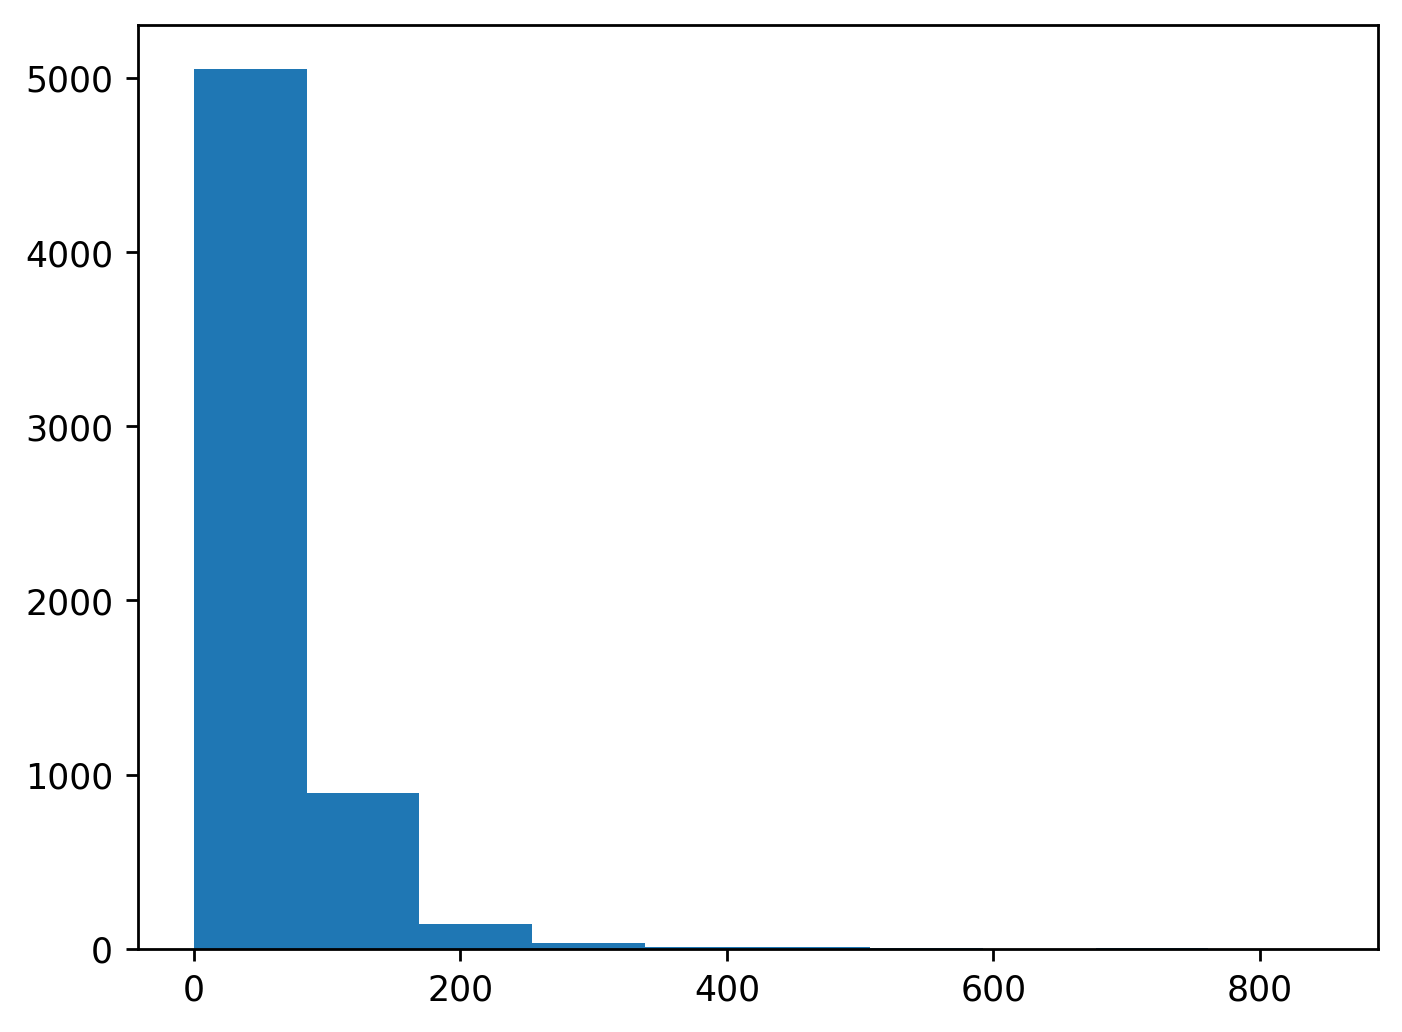

In [12]:
plt.hist(X.flatten())

In [13]:
X, y, feature_names = get_clean_dataset('diabetes', data_source='pmlb')
print('shapes', X.shape, y.shape, np.unique(y))

fetching diabetes from pmlb
shapes (768, 8) (768,) [0 1]


In [14]:
from imodels import C45TreeClassifier

m = C45TreeClassifier(max_rules=100)
m.fit(X, y)
print('mse', np.mean(np.square(m.predict(X) - y)))
print(m)

mse 0.07942708333333333
<?xml version="1.0" ?>
<GreedyTree>
	<X1 feature="128.0" flag="l" p="0.632">
		<X5 feature="26.5" flag="l" p="0.272">
			<X5 feature="18.2" flag="l" p="0.076">
				<X0 feature="8.0" flag="l" p="0.8">0.0</X0>
				<X0 feature="8.0" flag="r" p="0.2">1.0</X0>
			</X5>
			<X5 feature="18.2" flag="r" p="0.924">
				<X6 feature="0.6779999999999999" flag="l" p="0.844">0.0</X6>
				<X6 feature="0.6779999999999999" flag="r" p="0.156">
					<X6 feature="0.733" flag="l" p="0.053">1.0</X6>
					<X6 feature="0.733" flag="r" p="0.947">0.0</X6>
				</X6>
			</X5>
		</X5>
		<X5 feature="26.5" flag="r" p="0.728">
			<X7 feature="29.0" flag="l" p="0.51">
				<X0 feature="8.0" flag="l" p="0.994">
					<X2 feature="44.0" flag="l" p="0.022">
						<X5 feature="32.4" flag="l" p="0.5">0.0</X5>
						<X5 feature="32.4" flag="r" p="0.5">1.0</X5>
					</X2>
					<X2 feature="44.0" flag="r" p="0.978">
						<X5 feature="31.0" flag="l" p="0.326">0.0</X5>
						<X5 feature="31.0" flag="r" p=